10. In this problem, you will generate simulated data, and then perform PCA and K-means clustering on the data.

(a) Generate a simulated data set with 20 observations in each of</br>
three classes (i.e. 60 observations total), and 50 variables.</br>
</br>
Hint: There are a number of functions in Python that you can</br>
use to generate data. One example is the normal() method of</br>
the random() function in numpy; the uniform() method is another</br>
option. Be sure to add a mean shift to the observations in each</br>
class so that there are three distinct classes.</br>
</br>
模擬出三個明顯不同的類別資料，每個類別各有 20 筆觀測值、每筆有 50 個變數。</br>

In [10]:
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [11]:
np.random.seed(42)
n_classes = 3        # 共有三個類別
n_per_class = 20     # 每個類別有 20 筆資料
n_features = 50      # 每筆資料有 50 個變數（特徵）

# 產生三組不同平均值的常態分布資料
# loc=0 → 平均值是 0。
# scale=1 → 標準差是 1。
class1 = np.random.normal(loc=0, scale=1, size=(n_per_class, n_features)) # 平均值是 0 (20,50)
class2 = np.random.normal(loc=2, scale=1, size=(n_per_class, n_features)) # 平均值是 2 (20,50)
class3 = np.random.normal(loc=4, scale=1, size=(n_per_class, n_features)) # 平均值是 4 (20,50)

X = np.vstack((class1, class2, class3)) #vstack = 垂直堆疊三個矩陣 →  60 × 50 的大矩陣
y = np.array([0]*n_per_class + [1]*n_per_class + [2]*n_per_class)
# 產生標籤（label）：
# 前 20 筆是 0（class1）
# 接著 20 筆是 1（class2）
# 最後 20 筆是 2（class3）
print(X.shape)

(60, 50)


(b) Perform PCA on the 60 observations and plot the first two prin-</br>
cipal component score vectors. Use a different color to indicate</br>
the observations in each of the three classes. If the three classes</br>
appear separated in this plot, then continue on to part (c). If</br>
not, then return to part (a) and modify the simulation so that</br>
there is greater separation between the three classes. Do not</br>
continue to part (c) until the three classes show at least some</br>
separation in the first two principal component score vectors.</br>
分析（PCA）用前兩個主成分（PC1、PC2）把 50 維資料降到 2 維並畫出散點圖，觀察三個類別是否分得開。

         PC1       PC2  Class
0  16.022460  2.212653      0
1  14.164865  3.164022      0
2  14.648872 -0.154226      0
3  13.840466 -1.007877      0
4  13.350750  0.538432      0
(60, 3)


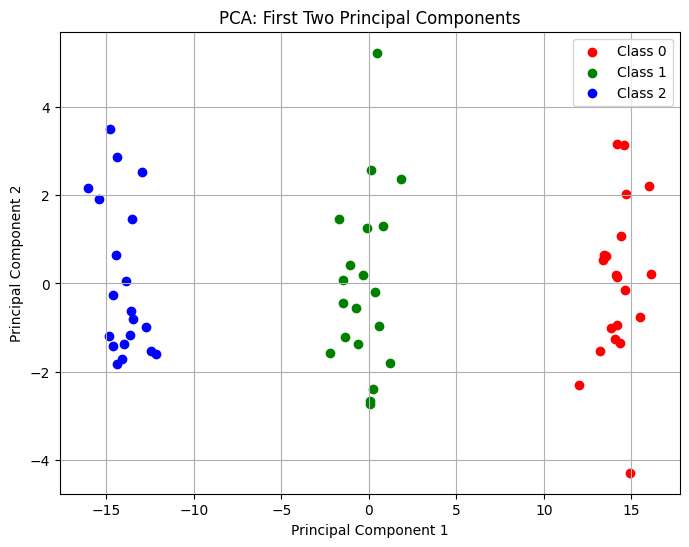

In [12]:
# 執行 PCA（降維到 2 維）
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 將 PCA 後存成 DataFrame，畫圖
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Class'] = y
print(df_pca.head())
print(df_pca.shape)

# 畫圖：三種顏色代表三個類別
colors = ['red', 'green', 'blue']
plt.figure(figsize=(8, 6))
for i, color in enumerate(colors):
    subset = df_pca[df_pca['Class'] == i]
    plt.scatter(subset['PC1'], subset['PC2'], color=color, label=f'Class {i}')

plt.title('PCA: First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

(c) Perform K-means clustering of the observations with K = 3.</br>
How well do the clusters that you obtained in K-means cluster-</br>
ing compare to the true class labels?</br>
</br>
Hint: You can use the pd.crosstab() function in Python to com-</br>
pare the true class labels to the class labels obtained by cluster-</br>
ing. Be careful how you interpret the results: K-means clustering</br>
will arbitrarily number the clusters, so you cannot simply check</br>
whether the true class labels and clustering labels are the same.</br>
</br>
用 K-means 將資料自動分成 3 群（K=3），再比較分群結果與真實標籤的吻合程度。

K-means Cluster   0   1   2
True Class                 
0                 0   0  20
1                20   0   0
2                 0  20   0


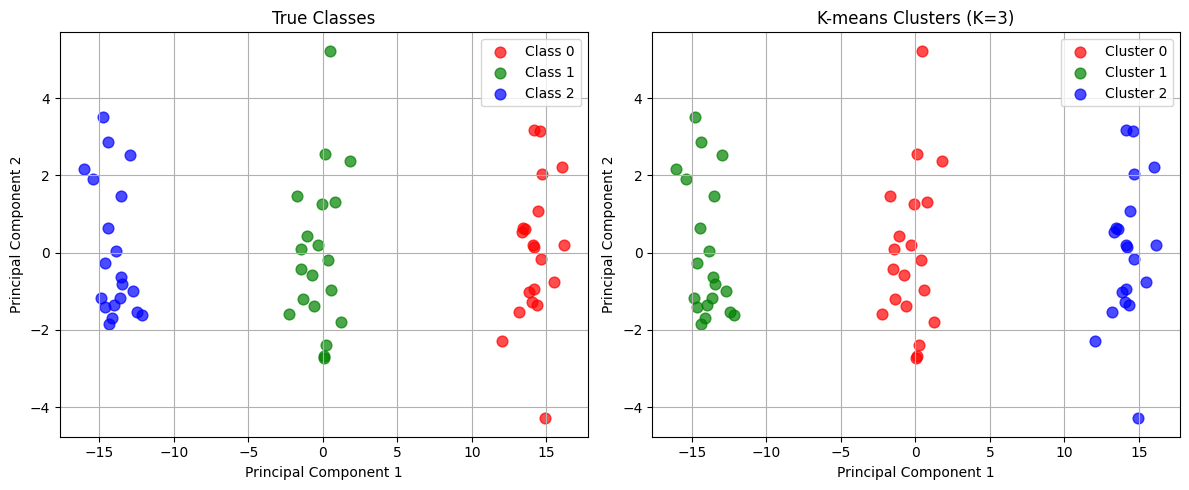

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# === K-means 分群 ===
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_cluster_labels = kmeans.fit_predict(X)

# 比較真實類別 vs K-means 分群結果
ct = pd.crosstab(y, kmeans_cluster_labels,
                 rownames=['True Class'],
                 colnames=['K-means Cluster'])
print(ct)
# === PCA 降維 ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# === 畫圖 ===
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 左圖：真實類別
for i, color in enumerate(colors):
    ax[0].scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                  color=color, s=60, alpha=0.7, label=f'Class {i}')
ax[0].set_title('True Classes')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')
ax[0].grid(True)
ax[0].legend()

# 右圖：K-means 結果
for i, color in enumerate(colors):
    ax[1].scatter(X_pca[kmeans_cluster_labels == i, 0], X_pca[kmeans_cluster_labels == i, 1],
                  color=color, s=60, alpha=0.7, label=f'Cluster {i}')
ax[1].set_title('K-means Clusters (K=3)')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


 K-means clustering 看出 True class = 0 ，K-means cluster 分配到2

(d) Perform K-means clustering with K = 2. Describe your results.

K-means Cluster   0   1
True Class             
0                 0  20
1                20   0
2                20   0


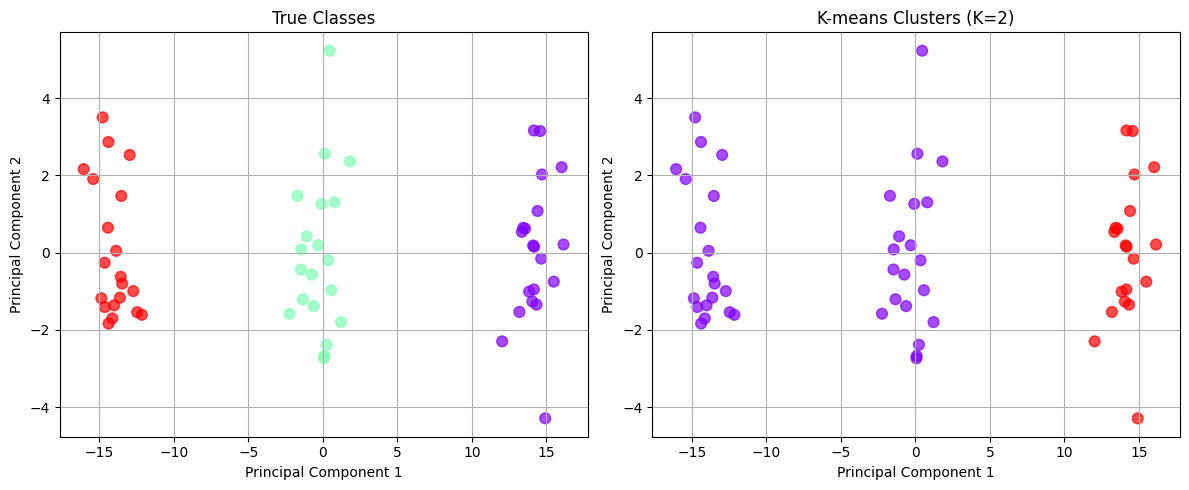

In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd

# === K-means 分群 (K = 2) ===
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_cluster_labels = kmeans.fit_predict(X)

# 比較真實類別 vs K-means 分群結果
ct = pd.crosstab(y, kmeans_cluster_labels,
                 rownames=['True Class'],
                 colnames=['K-means Cluster'])
print(ct)

# === PCA 降維 ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# === 畫圖 ===
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 左圖：真實類別
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='rainbow', s=60, alpha=0.7)
ax[0].set_title('True Classes')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')
ax[0].grid(True)

# 右圖：K-means 結果 (K=2)
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_cluster_labels, cmap='rainbow', s=60, alpha=0.7)
ax[1].set_title('K-means Clusters (K=2)')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')
ax[1].grid(True)

plt.tight_layout()
plt.show()


真實類別 0 完全被分到 cluster 1</br>
真實類別 1 全在 cluster 0</br>
真實類別 2 也在 cluster 0</br>

(e) Now perform K-means clustering with K = 4, and describe your
results.

K-means Cluster  0   1   2   3
True Class                    
0                0   0  20   0
1                6   0   0  14
2                0  20   0   0


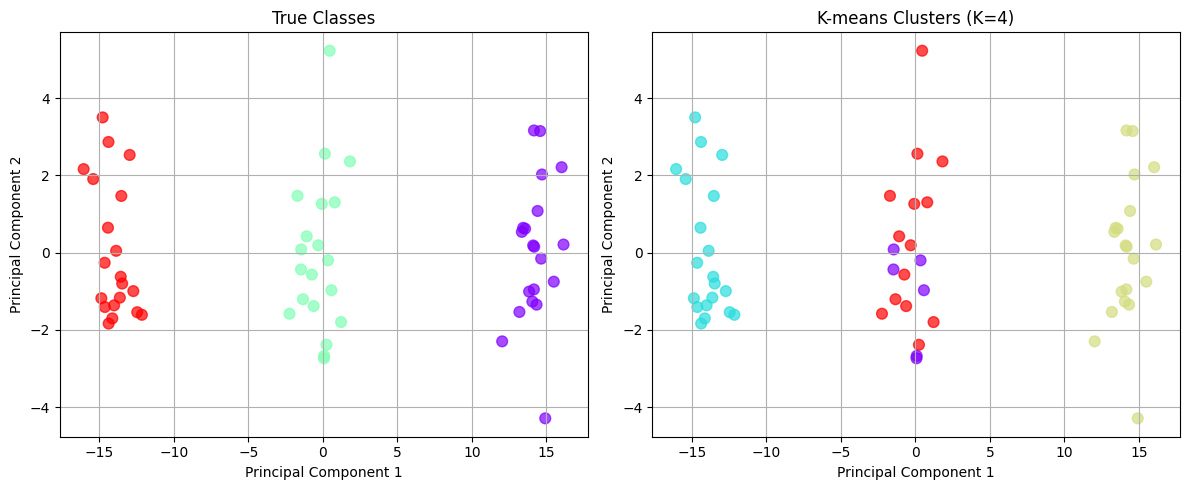

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd

# === K-means 分群 (K = 4) ===
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_cluster_labels = kmeans.fit_predict(X)

# 比較真實類別 vs K-means 分群結果
ct = pd.crosstab(y, kmeans_cluster_labels,
                 rownames=['True Class'],
                 colnames=['K-means Cluster'])
print(ct)

# === PCA 降維到 2 維，用於視覺化 ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# === 畫圖：真實類別 vs 分群結果 ===
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 左圖：真實類別
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='rainbow', s=60, alpha=0.7)
ax[0].set_title('True Classes')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')
ax[0].grid(True)

# 右圖：K-means 結果 (K=4)
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_cluster_labels, cmap='rainbow', s=60, alpha=0.7)
ax[1].set_title('K-means Clusters (K=4)')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')
ax[1].grid(True)

plt.tight_layout()
plt.show()

分成四群時，其中一個原本的類別被「切」成兩群。
表示 K 過大時，模型會「過度分割」，產生不必要的子群。
這是「高估群數」造成的誤差。

(f) Now perform K-means clustering with K = 3 on the first two</br>
principal component score vectors, rather than on the raw data.</br>
That is, perform K-means clustering on the 60 × 2 matrix of</br>
which the first column is the first principal component score</br>
vector, and the second column is the second principal component</br>
score vector. Comment on the results.</br>
看看如果先做 PCA 降維，再分群，結果是否差不多。</br>

K-means Cluster (on PCA)   0   1   2
True Class                          
0                          0  20   0
1                         20   0   0
2                          0   0  20


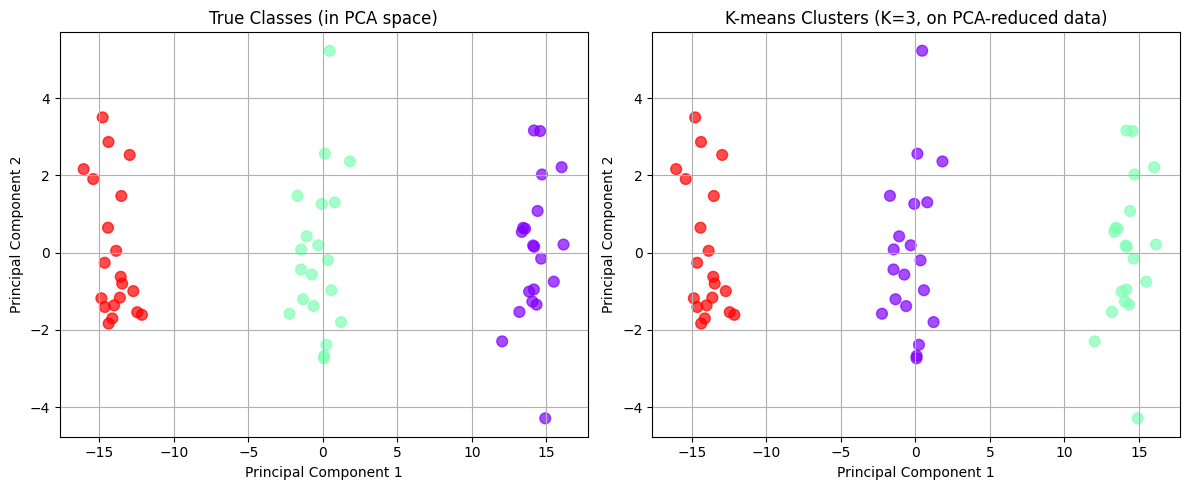

In [42]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd

# === (1) 先用 PCA 將原始 X 降到 2 維 ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# === (2) 在 2 維 PCA 分數上跑 K-means (K=3) ===
kmeans_pca = KMeans(n_clusters=3, random_state=42)
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

# === (3) 比較真實類別 vs K-means 結果 ===
ct = pd.crosstab(y, kmeans_pca_labels,
                 rownames=['True Class'],
                 colnames=['K-means Cluster (on PCA)'])
print(ct)

# === (4) 畫圖：真實類別 vs PCA 分群結果 ===
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 左圖：真實類別
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='rainbow', s=60, alpha=0.7)
ax[0].set_title('True Classes (in PCA space)')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')
ax[0].grid(True)

# 右圖：K-means (在 PCA 空間分群)
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_pca_labels, cmap='rainbow', s=60, alpha=0.7)
ax[1].set_title('K-means Clusters (K=3, on PCA-reduced data)')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')
ax[1].grid(True)

plt.tight_layout()
plt.show()



結果和直接用原始資料分群非常相似

PCA 先壓縮資料 → 去掉噪音與重複維度 →
K-means 在「更乾淨、代表性強」的空間中分群 → 結果更穩定、也更容易視覺化。

(g) Using the StandardScaler() estimator, perform K-means clus-</br>
tering with K = 3 on the data after scaling each variable to have</br>
standard deviation one. How do these results compare to those</br>
obtained in (b)? Explain.</br>
在做 K-means 分群之前，先把每個變數標準化 (standardize)，
再比較和原本沒標準化的結果有什麼不同。

K-means Cluster (Scaled)   0   1   2
True Class                          
0                          0   0  20
1                         20   0   0
2                          0  20   0


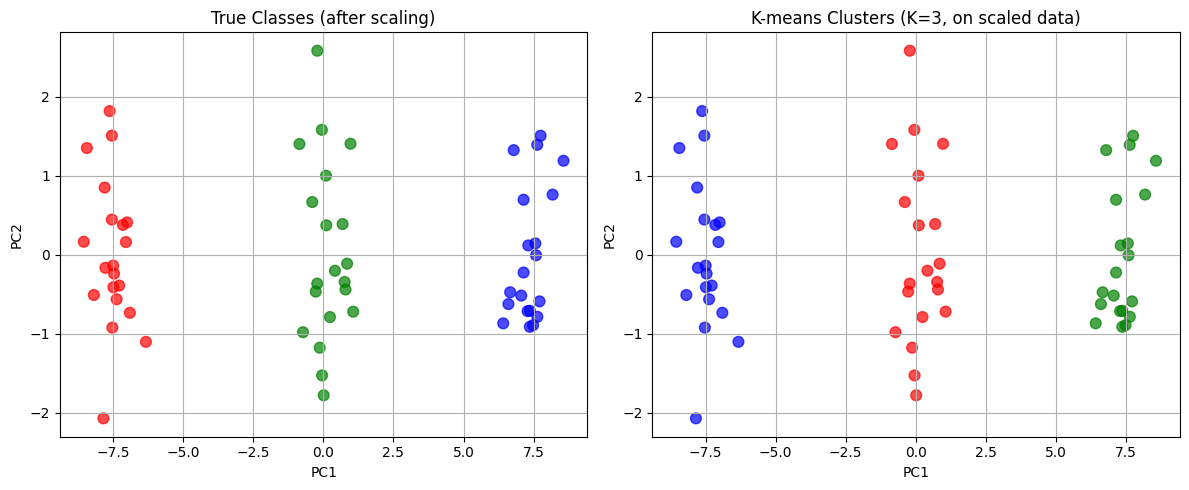

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# === (1) 標準化資料：每個變數平均=0、標準差=1 ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === (2) 在標準化後的資料上跑 K-means (K=3) ===
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
kmeans_scaled_labels = kmeans_scaled.fit_predict(X_scaled)

# === (3) 比較真實類別 vs K-means 結果 ===
ct = pd.crosstab(y, kmeans_scaled_labels,
                 rownames=['True Class'],
                 colnames=['K-means Cluster (Scaled)'])
print(ct)

# === (4) 用 PCA 把標準化後的結果畫出來 ===
pca = PCA(n_components=2)
X_scaled_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
custom_cmap = ListedColormap(['red', 'green', 'blue'])


# 左圖：真實類別
ax[0].scatter(X_scaled_pca[:, 0], X_scaled_pca[:, 1], c=y, cmap=custom_cmap, s=60, alpha=0.7)
ax[0].set_title('True Classes (after scaling)')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].grid(True)

# 右圖：K-means 結果
ax[1].scatter(X_scaled_pca[:, 0], X_scaled_pca[:, 1], c=kmeans_scaled_labels, cmap=custom_cmap, s=60, alpha=0.7)
ax[1].set_title('K-means Clusters (K=3, on scaled data)')
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2')
ax[1].grid(True)

plt.tight_layout()
plt.show()


標準化後的結果幾乎一樣。</br>
所以標準化只改變了變數的單位，不影響三群之間的相對位置。</br>
如果變數尺度差異很大（例如某些變數範圍 0–1、有些 0–1000），
→ 標準化後分群結果會明顯改善